# Campaign Best-Trial Sampling Review

This notebook finds the best completed trial in the latest active campaign, reloads its checkpoint, and reviews training examples, generated samples, and feasibility diagnostics.

Automatically selects the latest active NodeField campaign, finds the best completed trial so far, reloads its checkpoint, and samples graphs for inspection.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

from IPython.display import display
import pandas as pd

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo import (
    build_campaign_trial_artificial_plotter,
    collect_campaign_trial_results,
    draw_artificial_graphs,
    load_campaign_trial_generator,
    load_campaign_trial_training_examples,
    select_best_campaign_trial,
)
from conditional_node_field_graph_generator.extensions.demo.visualization import (
    infer_display_mode,
    plot_networkx_graphs,
    show_molecules,
)


PyTorch version: 2.12.0+cpu
CUDA available: False


In [2]:
CAMPAIGN_STATE_PATH = None  # keep None to auto-select the latest active campaign
DEVICE = "cpu"

In [3]:
ranking = collect_campaign_trial_results(
    repo_root=REPO_ROOT,
    campaign_state_path=CAMPAIGN_STATE_PATH,
)
selection = select_best_campaign_trial(
    repo_root=REPO_ROOT,
    campaign_state_path=CAMPAIGN_STATE_PATH,
)

print(f"Campaign: {selection.domain}/{selection.prefix}")
print(f"Best run: {selection.run_dir}")
print(f"Best trial: {selection.trial_dir.name}")
print(f"Checkpoint: {selection.checkpoint_path}")
display(ranking.head(20))


Campaign: artificial_graphs/artificial_graphs_small
Best run: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/artifact/artificial_graphs/artificial_graphs_small_20260701_165937_2c81e0
Best trial: trial_001
Checkpoint: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/artifact/artificial_graphs/artificial_graphs_small_20260701_165937_2c81e0/trials/trial_001/trials/trial_001/checkpoints/ConditionalNodeFieldGenerator_bf00619e0c504d31889bd41ccbce9b79/best-025-57.4389.ckpt


,average_num_violations,average_training_embedding_cosine_distance,campaign_trial_id,feasible_rate,generator_snapshot_path,loss_pdf_path,median_num_violations,optimization_score,results_csv_path,trial_id,...,prefix,run_dir,run_name,trial_dir,trial_name,metrics_path,config_path,checkpoint_path,campaign_state_path,campaign_status
0,114.875,0.035381,1,0.0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,118.0,4.06437,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,1,...,artificial_graphs_small,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,artificial_graphs_small_20260701_165937_2c81e0,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,trial_001,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,/run/media/fabrizio/06bb7271-2161-43a4-91f1-98...,running


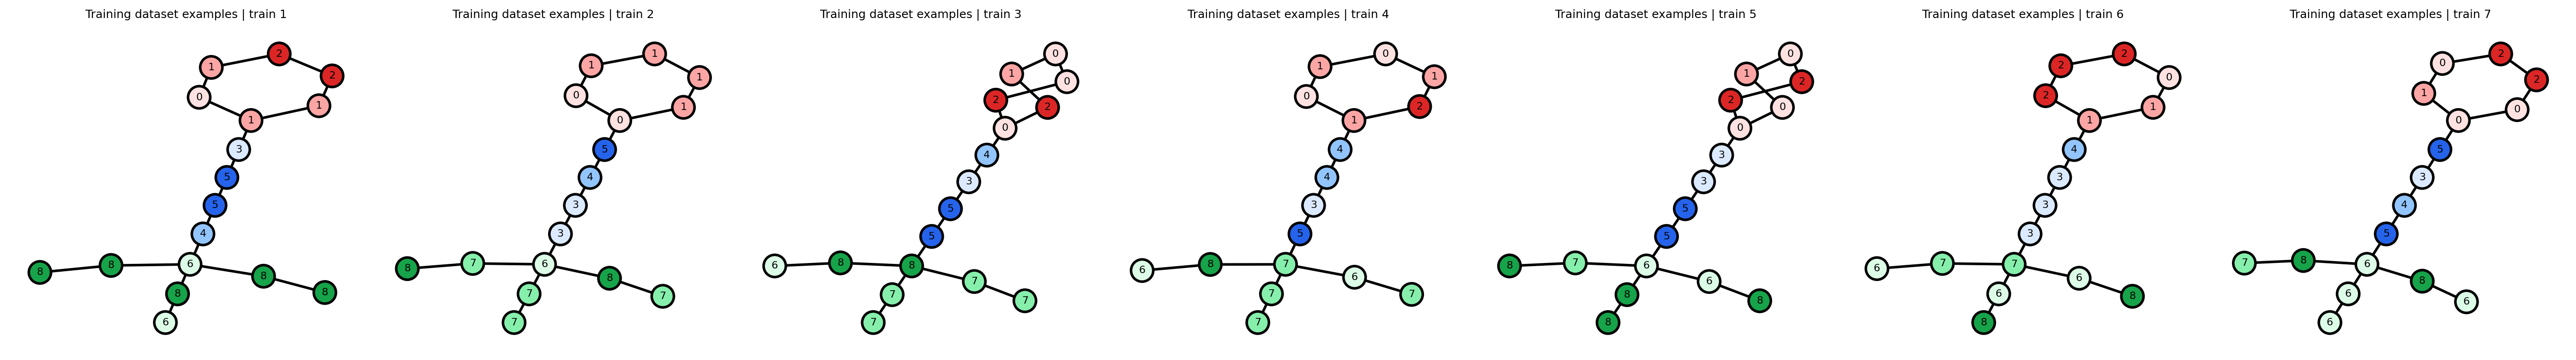

In [4]:
TRAINING_EXAMPLE_COUNT = 7

training_examples = load_campaign_trial_training_examples(
    selection,
    notebook_context=globals(),
    n_examples=TRAINING_EXAMPLE_COUNT,
)

example_titles = [f"train {index}" for index in range(1, len(training_examples) + 1)]
example_display_mode = infer_display_mode(training_examples)
artificial_plotter = None

if selection.domain == "artificial_graphs":
    artificial_plotter = build_campaign_trial_artificial_plotter(selection)
    draw_artificial_graphs(
        training_examples,
        n=len(training_examples),
        title="Training dataset examples",
        titles=example_titles,
        n_graphs_per_line=TRAINING_EXAMPLE_COUNT,
        plotter=artificial_plotter,
    )
elif example_display_mode == "molecule":
    show_molecules(
        training_examples,
        n=len(training_examples),
        title="Training dataset examples",
        legends=example_titles,
        n_graphs_per_line=TRAINING_EXAMPLE_COUNT,
    )
else:
    plot_networkx_graphs(
        training_examples,
        n_cols=TRAINING_EXAMPLE_COUNT,
        mode=example_display_mode,
        titles=example_titles,
    )


In [5]:
graph_generator = load_campaign_trial_generator(
    selection,
    notebook_context=globals(),
    device=DEVICE,
)

print(f"Loaded checkpoint: {selection.checkpoint_path}")
print("is_fitted_ =", getattr(graph_generator, "is_fitted_", None))


Loaded graph generator: graph-generator.pkl
/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/artifact/artificial_graphs/artificial_graphs_small_20260701_165937_2c81e0/trials/trial_001/model/graph-generator.pkl
Loaded checkpoint: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/artifact/artificial_graphs/artificial_graphs_small_20260701_165937_2c81e0/trials/trial_001/trials/trial_001/checkpoints/ConditionalNodeFieldGenerator_bf00619e0c504d31889bd41ccbce9b79/best-025-57.4389.ckpt
is_fitted_ = True


/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
N_SAMPLES = 2
FEASIBILITY_EFFORT = 2
FEASIBILITY_FILTER = "none"  # "none", "fallback", or "strict"

MAX_DISPLAY_GRAPHS = 16
N_COLS = 4

In [ ]:
generated_graphs = list(
    graph_generator.sample(
        n_samples=N_SAMPLES,
        feasibility_effort=FEASIBILITY_EFFORT,
        feasibility_filter=FEASIBILITY_FILTER,
    )
)

try:
    violation_counts = [
        float(value)
        for value in graph_generator.feasibility_estimator.number_of_violations(generated_graphs)
    ]
    violation_error = None
except SystemError as exc:
    violation_counts = [float("nan")] * len(generated_graphs)
    violation_error = f"{type(exc).__name__}: {exc}"
    print(f"Violation summary unavailable: {violation_error}")
sample_summary = {
    "n_samples": N_SAMPLES,
    "returned_samples": len(generated_graphs),
    "feasibility_effort": FEASIBILITY_EFFORT,
    "feasibility_filter": FEASIBILITY_FILTER,
    "average_num_violations": (
        sum(violation_counts) / len(violation_counts) if violation_counts else float("nan")
    ),
    "feasible_rate": (
        sum(value == 0 for value in violation_counts) / len(violation_counts)
        if violation_counts and violation_error is None
        else float("nan")
    ),
    "violation_error": violation_error,
}

display(pd.DataFrame([sample_summary]))


Sampling 2 ILP graphs


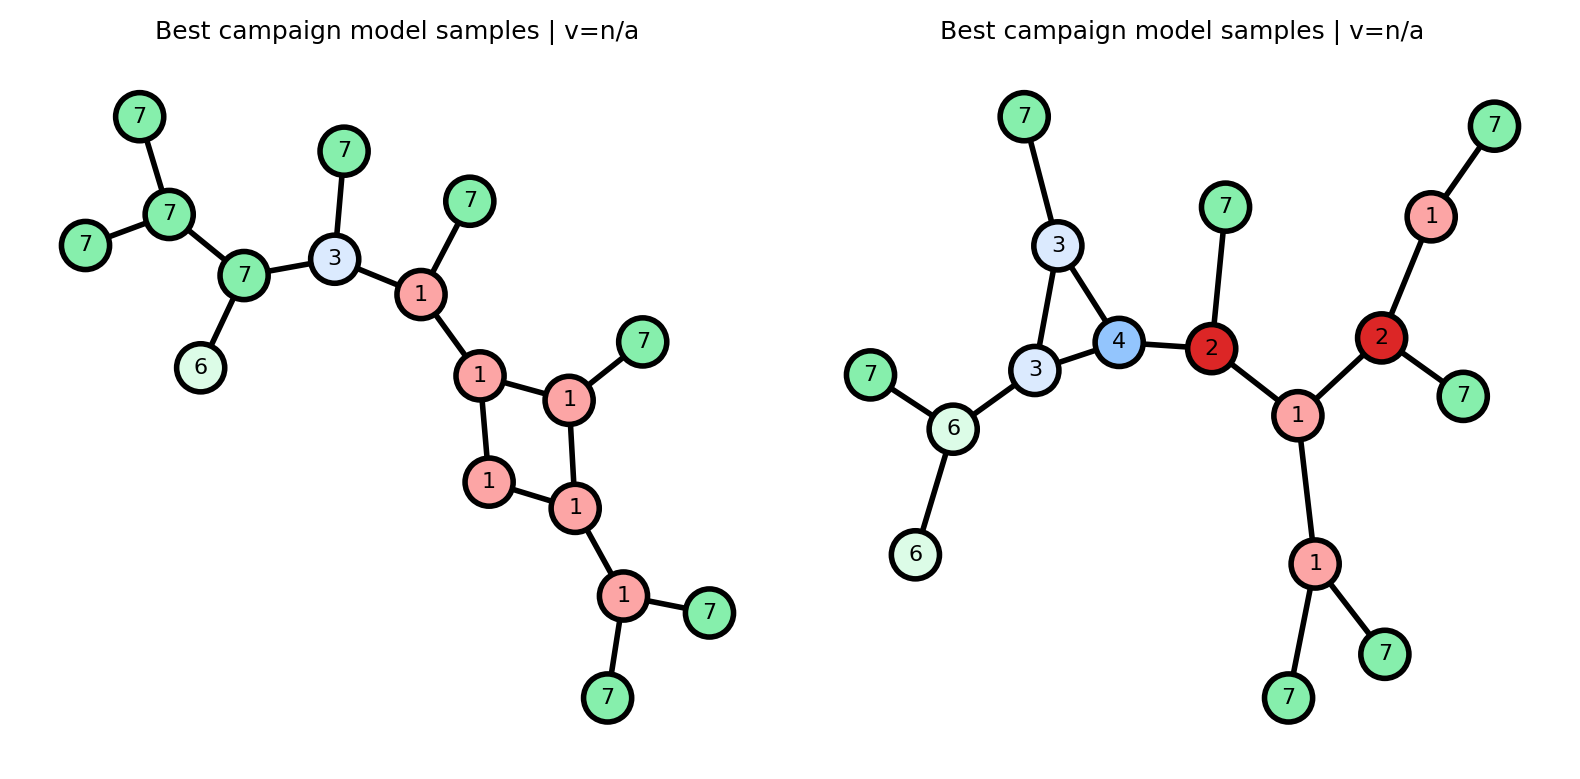

In [ ]:
graphs_to_show = generated_graphs[:MAX_DISPLAY_GRAPHS]
titles = [
    "v=n/a" if pd.isna(value) else f"v={value:g}"
    for value in violation_counts[:len(graphs_to_show)]
]
display_mode = infer_display_mode(graphs_to_show)

if selection.domain == "artificial_graphs":
    artificial_plotter = artificial_plotter or build_campaign_trial_artificial_plotter(selection)
    draw_artificial_graphs(
        graphs_to_show,
        title="Best campaign model samples",
        titles=titles,
        n_graphs_per_line=N_COLS,
        plotter=artificial_plotter,
    )
elif display_mode == "molecule":
    show_molecules(
        graphs_to_show,
        n=len(graphs_to_show),
        title="Best campaign model samples",
        legends=titles,
        n_graphs_per_line=N_COLS,
    )
else:
    plot_networkx_graphs(
        graphs_to_show,
        n_cols=N_COLS,
        mode=display_mode,
        titles=titles,
    )
